# Multi-Sample Per-Question Latent Analysis

This notebook is for the offline collection setting where each question has multiple sampled responses.

It focuses on the question-level structure enabled by fields such as:
- `question_uid`
- `sample_idx`
- `success`

Main goals:
1. verify the multi-sample collection integrity,
2. compute per-question success rates,
3. compare within-question latent dispersion for successful vs failed samples,
4. visualize representative questions in PCA space.

In [1]:
from pathlib import Path
import json
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch

from research.buffer import ParquetLatentBuffer
from research.latent.codec import deserialize_latent_tensor

OUTPUT_DIR = Path('/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b') # allenai_llama_3_1_tulu_3_8b
OUTPUT_DIR = Path('/workspace/outputs/offline_math500_temp1_k32/allenai_llama_3_1_tulu_3_8b')
USE_REASONING_SPAN = True
MIN_GROUP_SIZE = 2
RANDOM_SEED = 1
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


def load_jsonl(path: Path):
    rows = []
    with path.open(encoding='utf-8') as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

metadata_path = OUTPUT_DIR / 'metadata.jsonl'
buffer_dir = OUTPUT_DIR / 'buffer'
summary_path = OUTPUT_DIR / 'collection_summary.json'

assert metadata_path.exists(), f'missing metadata: {metadata_path}'
assert buffer_dir.exists(), f'missing buffer: {buffer_dir}'

metadata_rows = load_jsonl(metadata_path)
metadata_by_uid = {row['uid']: row for row in metadata_rows}

print(f'Loaded {len(metadata_rows)} metadata rows from {metadata_path}')
if summary_path.exists():
    print(summary_path.read_text(encoding='utf-8'))

Loaded 3200 metadata rows from /workspace/outputs/offline_math500_temp1_k32/allenai_llama_3_1_tulu_3_8b/metadata.jsonl
{
  "model": "allenai/Llama-3.1-Tulu-3-8B",
  "input": "/workspace/data/math500_local_allenai_llama_3_1_tulu_3_8b.jsonl",
  "output_dir": "/workspace/outputs/offline_math500_temp1_k32/allenai_llama_3_1_tulu_3_8b",
  "buffer_dir": "/workspace/outputs/offline_math500_temp1_k32/allenai_llama_3_1_tulu_3_8b/buffer",
  "metadata_path": "/workspace/outputs/offline_math500_temp1_k32/allenai_llama_3_1_tulu_3_8b/metadata.jsonl",
  "processed_examples": 100,
  "saved_questions": 100,
  "saved_sequences": 3199,
  "skipped_existing_sequences": 0,
  "num_samples_per_question": 32,
  "temperature": 1.0,
  "seed": 100001,
  "resume": true,
  "layer_index": -1,
  "latent_dtype": "fp16",
  "device": "cuda",
  "buffer_stats": {
    "buffer/total_samples": 3199,
    "buffer/total_shards": 3199,
    "buffer/pending_rows": 0
  }
}



In [2]:
# Load latent rows.
buffer = ParquetLatentBuffer(
    root_dir=str(buffer_dir),
    shard_max_samples=256,
    compression='zstd',
    max_disk_gb=1000.0,
)
rows = list(buffer.iter_rows())
rows = [row for row in rows if row['uid'] in metadata_by_uid]
print(f'Loaded {len(rows)} latent rows from buffer')
print('Buffer stats:', buffer.get_stats())

Loaded 3199 latent rows from buffer
Buffer stats: {'buffer/total_samples': 3199, 'buffer/total_shards': 3199, 'buffer/pending_rows': 0}


In [3]:
def extract_sequence_for_analysis(row, meta, use_reasoning_span=True):
    seq = deserialize_latent_tensor(
        row['latent_blob'],
        seq_len=int(row['response_length']),
        hidden_dim=int(row['hidden_dim']),
        dtype=str(row['dtype']),
    ).float()

    start = 0
    end = seq.shape[0]
    if use_reasoning_span and meta.get('think_token_start') is not None and meta.get('think_token_end') is not None:
        start = int(meta['think_token_start'])
        end = int(meta['think_token_end'])
        start = max(0, min(start, seq.shape[0]))
        end = max(start + 1, min(end, seq.shape[0]))
    return seq[start:end]

samples = []
for row in rows:
    meta = metadata_by_uid[row['uid']]
    seq = extract_sequence_for_analysis(row, meta, use_reasoning_span=USE_REASONING_SPAN)
    pooled_mean = seq.mean(dim=0)
    pooled_last = seq[-1]
    step_deltas = seq[1:] - seq[:-1] if seq.shape[0] > 1 else torch.zeros_like(seq[:1])
    path_length = float(step_deltas.norm(dim=-1).sum().item()) if seq.shape[0] > 1 else 0.0
    mean_norm = float(seq.norm(dim=-1).mean().item())
    question_uid = meta.get('question_uid', meta['uid'])
    sample_idx = int(meta.get('sample_idx', 0))
    samples.append({
        'uid': row['uid'],
        'question_uid': question_uid,
        'sample_idx': sample_idx,
        'success': bool(meta['success']),
        'score_accuracy': float(meta['score_accuracy']),
        'response_length': int(meta['response_length']),
        'analysis_length': int(seq.shape[0]),
        'path_length': path_length,
        'mean_norm': mean_norm,
        'mean_feature': pooled_mean.numpy(),
        'last_feature': pooled_last.numpy(),
        'question': meta['question'],
        'response': meta['response'],
        'final_answer_text': meta.get('final_answer_text'),
    })

print(f'Prepared {len(samples)} samples')

Prepared 3199 samples


In [4]:
# Integrity checks for the multi-sample setup.
by_question = defaultdict(list)
for sample in samples:
    by_question[sample['question_uid']].append(sample)

question_sizes = [len(v) for v in by_question.values()]
print('questions:', len(by_question))
print('min samples/question:', min(question_sizes))
print('max samples/question:', max(question_sizes))
print('mean samples/question:', float(np.mean(question_sizes)))

example_qid = next(iter(by_question))
print('example question_uid:', example_qid)
print('example sample_idx set:', sorted(s['sample_idx'] for s in by_question[example_qid])[:10], '...')

questions: 100
min samples/question: 31
max samples/question: 32
mean samples/question: 31.99
example question_uid: test/precalculus/807.json
example sample_idx set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ...


In [5]:
def summarize(values):
    arr = np.asarray(values, dtype=np.float64)
    return {
        'n': int(arr.size),
        'mean': float(arr.mean()) if arr.size else None,
        'std': float(arr.std()) if arr.size else None,
        'min': float(arr.min()) if arr.size else None,
        'max': float(arr.max()) if arr.size else None,
    }

question_rows = []
for qid, group in by_question.items():
    n = len(group)
    n_success = sum(int(x['success']) for x in group)
    n_failure = n - n_success
    success_rate = n_success / n if n else 0.0
    question_rows.append({
        'question_uid': qid,
        'question': group[0]['question'],
        'n_samples': n,
        'n_success': n_success,
        'n_failure': n_failure,
        'success_rate': success_rate,
        'mean_response_length': float(np.mean([x['response_length'] for x in group])),
        'mean_path_length': float(np.mean([x['path_length'] for x in group])),
    })

print('Success rate across questions:', summarize([row['success_rate'] for row in question_rows]))
print('Questions with both success and failure:', sum(int(row['n_success'] > 0 and row['n_failure'] > 0) for row in question_rows))

Success rate across questions: {'n': 100, 'mean': 0.47502016129032254, 'std': 0.36542864512346185, 'min': 0.0, 'max': 1.0}
Questions with both success and failure: 81


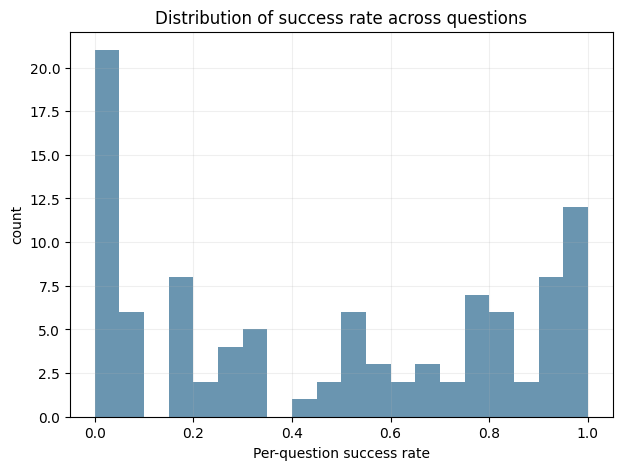

In [6]:
plt.figure(figsize=(7, 5))
plt.hist([row['success_rate'] for row in question_rows], bins=20, color='#457b9d', alpha=0.8)
plt.xlabel('Per-question success rate')
plt.ylabel('count')
plt.title('Distribution of success rate across questions')
plt.grid(alpha=0.2)
plt.show()

In [7]:
def mean_pairwise_distance(mat):
    if len(mat) < 2:
        return None
    mat = np.asarray(mat, dtype=np.float32)
    sq = np.sum(mat ** 2, axis=1, keepdims=True)
    d2 = np.maximum(sq + sq.T - 2 * mat @ mat.T, 0.0)
    iu = np.triu_indices(len(mat), k=1)
    vals = np.sqrt(d2[iu])
    return float(vals.mean()) if vals.size else None


def mean_distance_to_centroid(mat):
    if len(mat) < 2:
        return None
    mat = np.asarray(mat, dtype=np.float32)
    centroid = mat.mean(axis=0, keepdims=True)
    d = np.linalg.norm(mat - centroid, axis=1)
    return float(d.mean())


dispersion_rows = []
for qid, group in by_question.items():
    success_last = [x['last_feature'] for x in group if x['success']]
    failure_last = [x['last_feature'] for x in group if not x['success']]
    if len(success_last) >= MIN_GROUP_SIZE or len(failure_last) >= MIN_GROUP_SIZE:
        dispersion_rows.append({
            'question_uid': qid,
            'n_success': len(success_last),
            'n_failure': len(failure_last),
            'success_pairwise': mean_pairwise_distance(success_last),
            'failure_pairwise': mean_pairwise_distance(failure_last),
            'success_centroid': mean_distance_to_centroid(success_last),
            'failure_centroid': mean_distance_to_centroid(failure_last),
        })

success_pairwise = [r['success_pairwise'] for r in dispersion_rows if r['success_pairwise'] is not None]
failure_pairwise = [r['failure_pairwise'] for r in dispersion_rows if r['failure_pairwise'] is not None]
print('Successful last-token dispersion:', summarize(success_pairwise))
print('Failed last-token dispersion:', summarize(failure_pairwise))

Successful last-token dispersion: {'n': 79, 'mean': 162.58269505561154, 'std': 20.404617663950866, 'min': 43.95012283325195, 'max': 203.91448974609375}
Failed last-token dispersion: {'n': 88, 'mean': 170.85096940127286, 'std': 15.381588235719946, 'min': 91.33882904052734, 'max': 200.53639221191406}


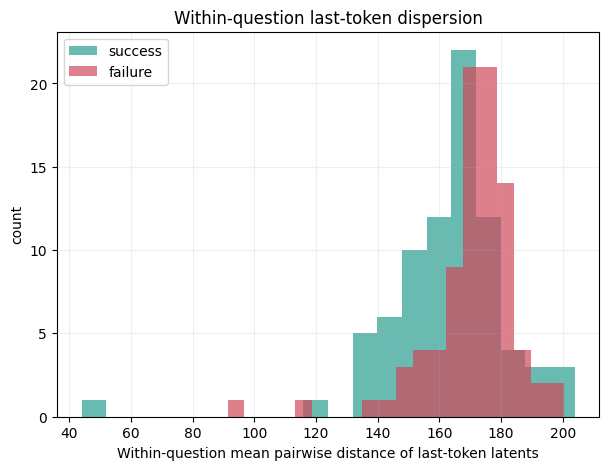

In [8]:
plt.figure(figsize=(7, 5))
if success_pairwise:
    plt.hist(success_pairwise, bins=20, alpha=0.7, label='success', color='#2a9d8f')
if failure_pairwise:
    plt.hist(failure_pairwise, bins=20, alpha=0.7, label='failure', color='#d1495b')
plt.xlabel('Within-question mean pairwise distance of last-token latents')
plt.ylabel('count')
plt.title('Within-question last-token dispersion')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Questions with both success and failure and enough samples: 67
failure_pairwise - success_pairwise: {'n': 67, 'mean': 8.047150113689366, 'std': 22.702064993774503, 'min': -42.71558380126953, 'max': 120.80224609375}


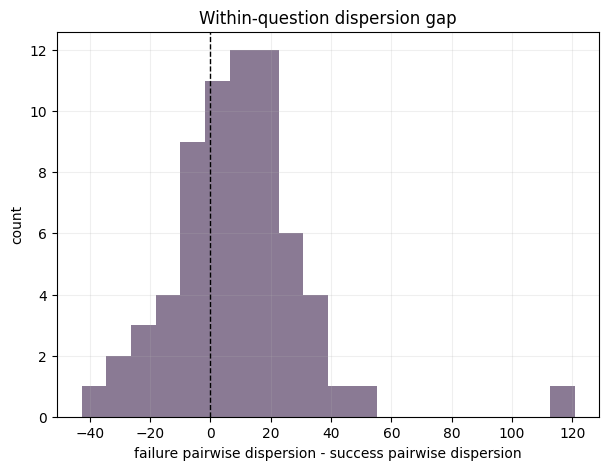

In [9]:
# Compare success and failure dispersion only on questions that have both classes.
paired_questions = [
    r for r in dispersion_rows
    if r['success_pairwise'] is not None and r['failure_pairwise'] is not None
]

deltas = np.asarray([r['failure_pairwise'] - r['success_pairwise'] for r in paired_questions], dtype=np.float32)
print('Questions with both success and failure and enough samples:', len(paired_questions))
print('failure_pairwise - success_pairwise:', summarize(deltas))

plt.figure(figsize=(7, 5))
plt.hist(deltas, bins=20, color='#6d597a', alpha=0.8)
plt.axvline(0.0, color='black', linestyle='--', linewidth=1)
plt.xlabel('failure pairwise dispersion - success pairwise dispersion')
plt.ylabel('count')
plt.title('Within-question dispersion gap')
plt.grid(alpha=0.2)
plt.show()

In [10]:
def pca_project(x, n_components=2):
    x = np.asarray(x, dtype=np.float32)
    x_centered = x - x.mean(axis=0, keepdims=True)
    _, s, vt = np.linalg.svd(x_centered, full_matrices=False)
    coords = x_centered @ vt[:n_components].T
    explained = (s ** 2) / max(1, x.shape[0] - 1)
    explained_ratio = explained / explained.sum()
    return coords, explained_ratio[:n_components], vt[:n_components], x.mean(axis=0, keepdims=True)


def plot_question_pca(question_uid):
    group = by_question[question_uid]
    feats = np.stack([x['last_feature'] for x in group], axis=0)
    labels = np.asarray([int(x['success']) for x in group])
    coords, var_ratio, _, _ = pca_project(feats, n_components=2)
    plt.figure(figsize=(6, 5))
    failure = labels == 0
    success = labels == 1
    if failure.any():
        plt.scatter(coords[failure, 0], coords[failure, 1], c='#d1495b', s=35, alpha=0.8, label='failure')
    if success.any():
        plt.scatter(coords[success, 0], coords[success, 1], c='#2a9d8f', s=35, alpha=0.8, label='success')
    plt.title(question_uid)
    plt.xlabel(f'PC1 ({var_ratio[0] * 100:.1f}% var)')
    plt.ylabel(f'PC2 ({var_ratio[1] * 100:.1f}% var)')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

In [11]:
# Show a few representative questions with both success and failure.
interesting = [r for r in question_rows if r['n_success'] > 0 and r['n_failure'] > 0]
interesting = sorted(interesting, key=lambda r: abs(r['success_rate'] - 0.5))
print('Representative mixed-outcome questions:')
for row in interesting[:5]:
    print(row['question_uid'], 'success_rate=', row['success_rate'], 'n_success=', row['n_success'], 'n_failure=', row['n_failure'])

Representative mixed-outcome questions:
test/precalculus/1300.json success_rate= 0.5 n_success= 16 n_failure= 16
test/algebra/2193.json success_rate= 0.46875 n_success= 15 n_failure= 17
test/counting_and_probability/134.json success_rate= 0.46875 n_success= 15 n_failure= 17
test/number_theory/627.json success_rate= 0.53125 n_success= 17 n_failure= 15
test/algebra/2046.json success_rate= 0.53125 n_success= 17 n_failure= 15


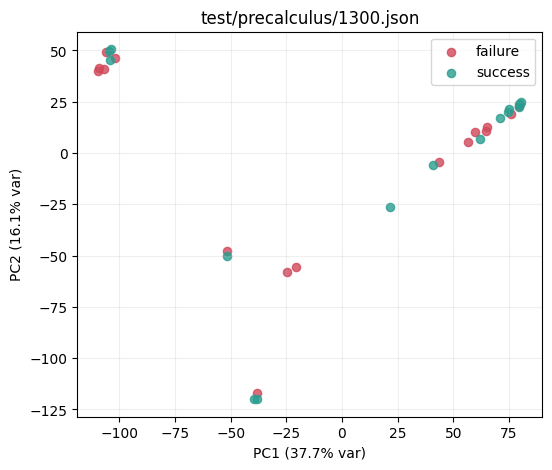

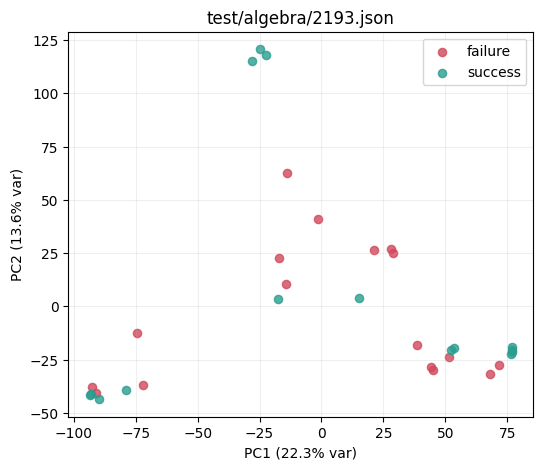

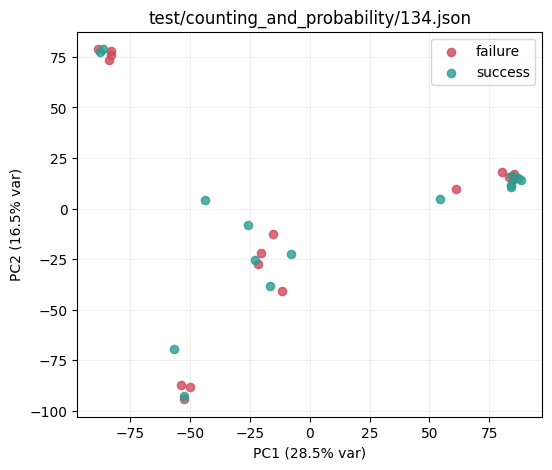

In [12]:
# Plot PCA for a few representative questions.
for row in interesting[:3]:
    plot_question_pca(row['question_uid'])

In [13]:
def show_question_examples(question_uid, n_success=2, n_failure=2):
    group = by_question[question_uid]
    success_group = [x for x in group if x['success']]
    failure_group = [x for x in group if not x['success']]

    print('=' * 140)
    print('question_uid:', question_uid)
    print('question:', group[0]['question'])
    print('n_success:', len(success_group), 'n_failure:', len(failure_group))

    print('Successful samples')
    for item in success_group[:n_success]:
        print('-' * 100)
        print('sample_idx:', item['sample_idx'], 'answer:', item['final_answer_text'])
        print(item['response'][:800])

    print('Failed samples')
    for item in failure_group[:n_failure]:
        print('-' * 100)
        print('sample_idx:', item['sample_idx'], 'answer:', item['final_answer_text'])
        print(item['response'][:800])

In [ ]:
# Print a couple of sampled responses for one mixed-outcome question.
if interesting:
    show_question_examples(interesting[0]['question_uid'])

question_uid: test/precalculus/1300.json
question: If $\mathbf{a} = \begin{pmatrix} 1 \\ 1 \\ 1 \end{pmatrix},$ then find the vector $\mathbf{v}$ such that $\mathbf{a} \cdot \mathbf{v} = 2$ and $\mathbf{a} \times \mathbf{v} = \begin{pmatrix} 1 \\ -2 \\ 1 \end{pmatrix}.$
n_success: 16 n_failure: 16
Successful samples
----------------------------------------------------------------------------------------------------
sample_idx: 1 answer: \begin{pmatrix} -\frac{1}{3} \\ \frac{2}{3} \\ \frac{5}{3} \end{pmatrix}
<think> Given \(\mathbf{a} = \begin{pmatrix} 1 \\ 1 \\ 1 \end{pmatrix},\) we want to find a vector \(\mathbf{v} = \begin{pmatrix} x \\ y \\ z \end{pmatrix}\) such that \(\mathbf{a} \cdot \mathbf{v} = 2\) and \(\mathbf{a} \times \mathbf{v} = \begin{pmatrix} 1 \\ -2 \\ 1 \end{pmatrix}.\)

First, consider the dot product equation:

\[
\mathbf{a} \cdot \mathbf{v} = 1 \cdot x + 1 \cdot y + 1 \cdot z = x + y + z = 2
\]

Next, consider the cross product equation:

\[
\mathbf{a} \times \ma

: 